In [1]:
%load_ext autoreload
%autoreload 2

# OpenCV model calibration

This notebook shows how to calibrate an OpenCV-compatible camera model and analyze the result.

OpenCV models are compatible with almost all standard tools, and are perfectly fine for most applications.

In [2]:
import cv2
import imageio.v3 as iio
import mediapy
from pathlib import Path

import lensboy as lb
import lensboy.analysis as lba

First, load the images, and look at an example image.

""

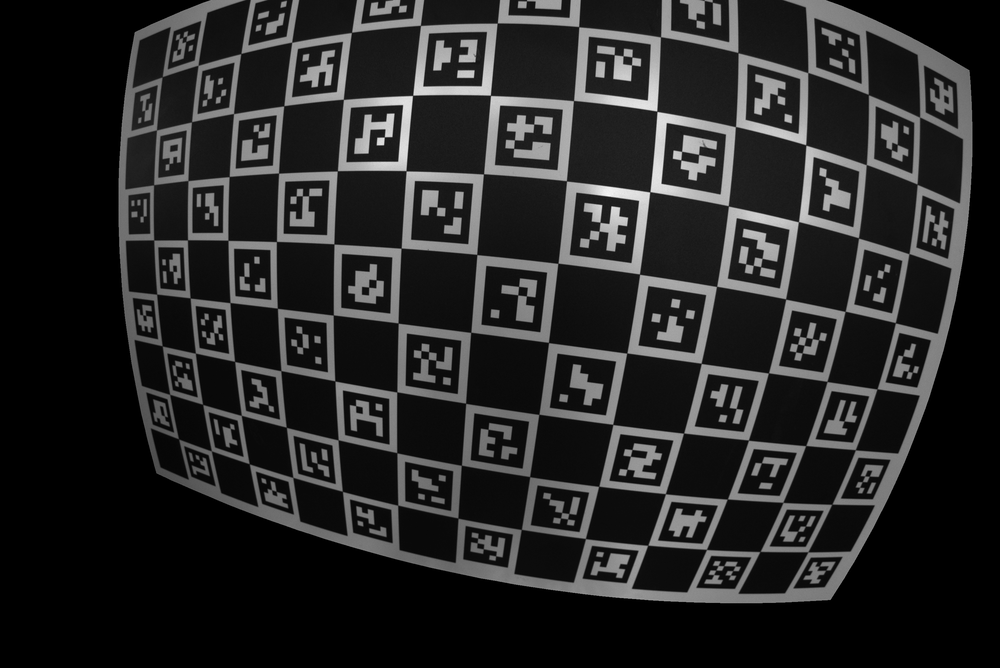

In [3]:
img_directory = Path("../data/images/wide_angle_charuco_private")
img_paths = sorted(img_directory.glob("*.png"))
imgs = [iio.imread(pth) for pth in img_paths]

# if you're running the notebook yourself, you can use this for synthetic images
# from lensboy.demo import make_synthetic_images
# imgs = make_synthetic_images()

mediapy.show_image(imgs[0], width=1000)

Extract charuco detections from the images.

In [4]:
board = cv2.aruco.CharucoBoard(
    (14, 9), 40, 30, cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
)
target_points, frames, image_indices = lb.extract_frames_from_charuco(board, imgs)
used_imgs = [imgs[i] for i in image_indices]

img_height, img_width = used_imgs[0].shape[:2]

Detecting charuco: 101/101 (100.0%)
Detected charuco in 101/101 images


Let's see how well our data covers the image space:

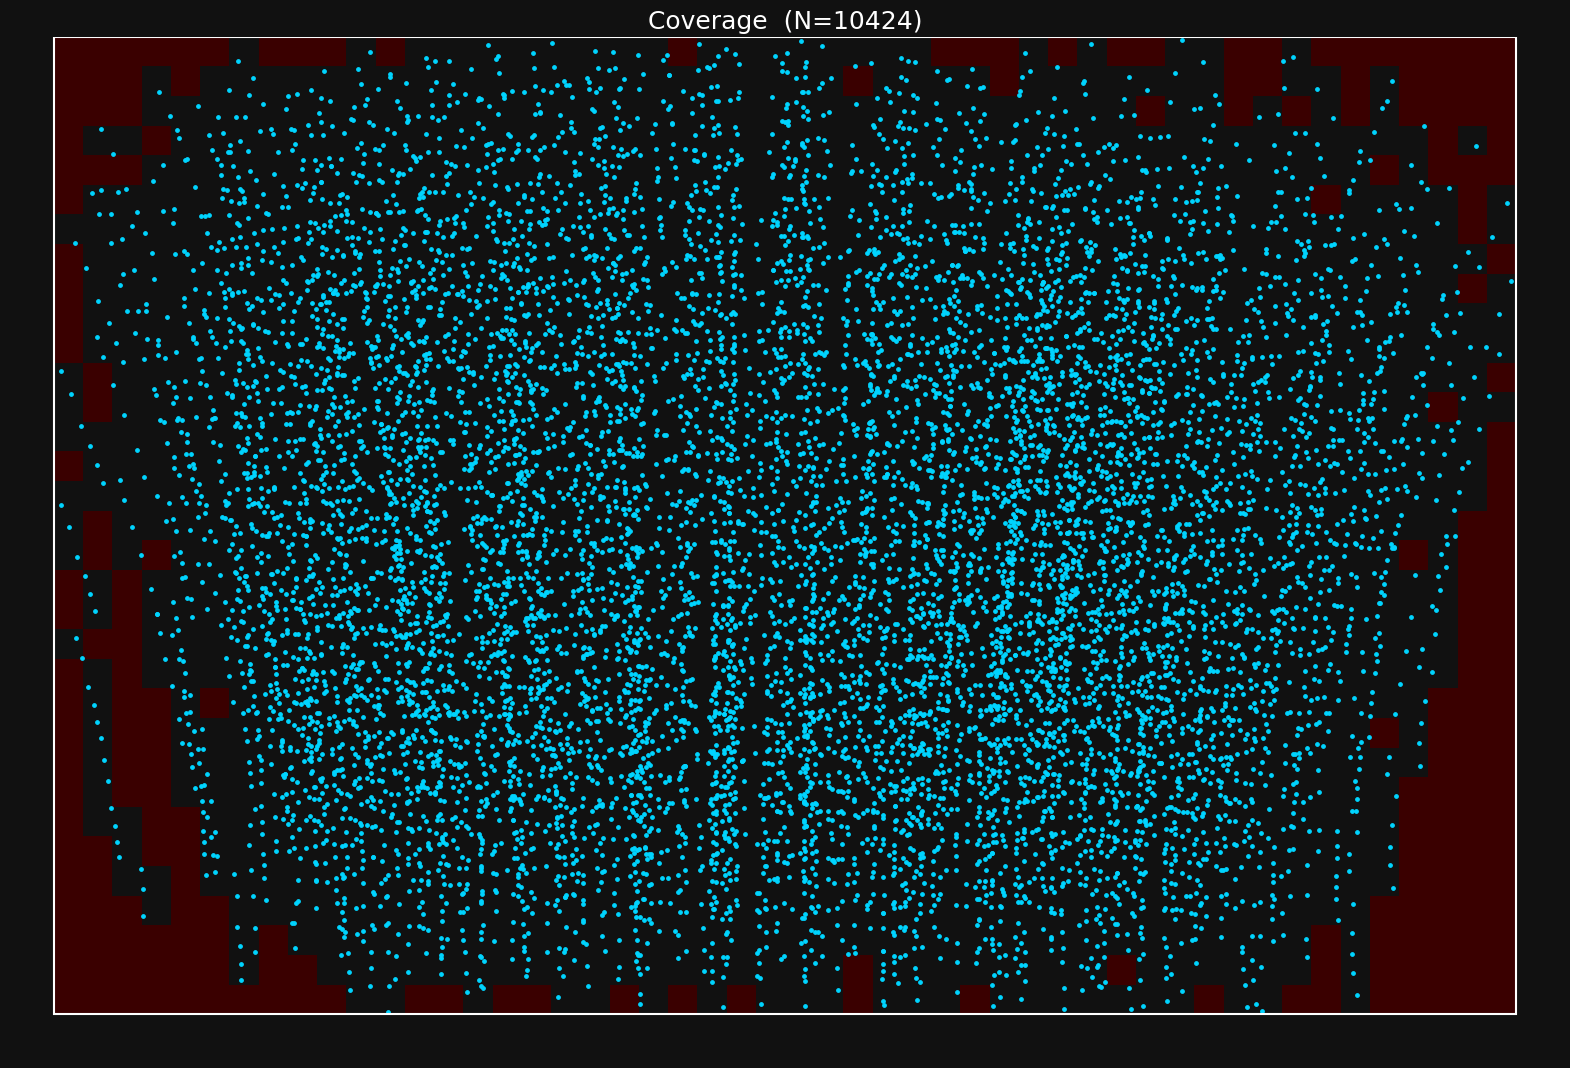

In [5]:
lba.plot_detection_coverage(frames, image_width=img_width, image_height=img_height)

Pretty good, especially for such a wide-angle camera.

# Calibrate

We'll use all available distortion coefficients for the best possible fit.

In [6]:
config = lb.OpenCVConfig(
    image_height=img_height,
    image_width=img_width,
    # all distortion coefficients
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)
result = lb.calibrate_camera(target_points, frames, camera_model_config=config)

Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 101/101 frames
OpenCV pass 1: 0.6s (mean reproj=0.151px, worst=4.969px)
Outlier filtering: 90/10424 (0.9%) — re-optimizing...
OpenCV pass 2: 0.4s (mean reproj=0.140px, worst=0.609px)
Outlier filtering: 116/10424 (1.1%) — re-optimizing...
OpenCV pass 3: 0.1s (mean reproj=0.138px, worst=0.543px)
Target warp max deflection: 0.4683 (target units)


We can see a few things from the logs:
* Outlier filtering was performed. A low percentage is good - I would start to worry if it went over a few percent.
* The optimizer estimated some target warp. This is useful, as flat boards like these are almost never completely flat.

# Analyze result

Let's check the geometry that the solver ended up with:

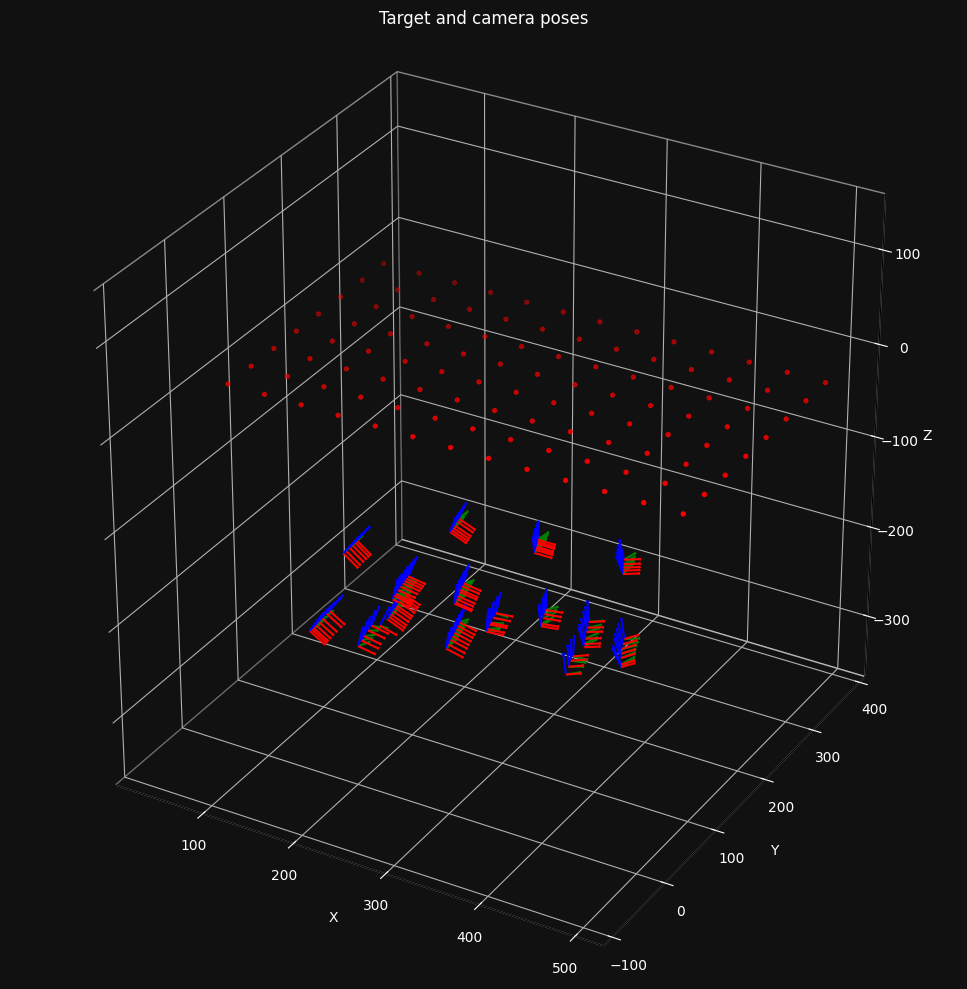

In [7]:
result.plot_target_and_poses()

Looks about right. Let's sanity check that the reprojected target points look good in an image:

""

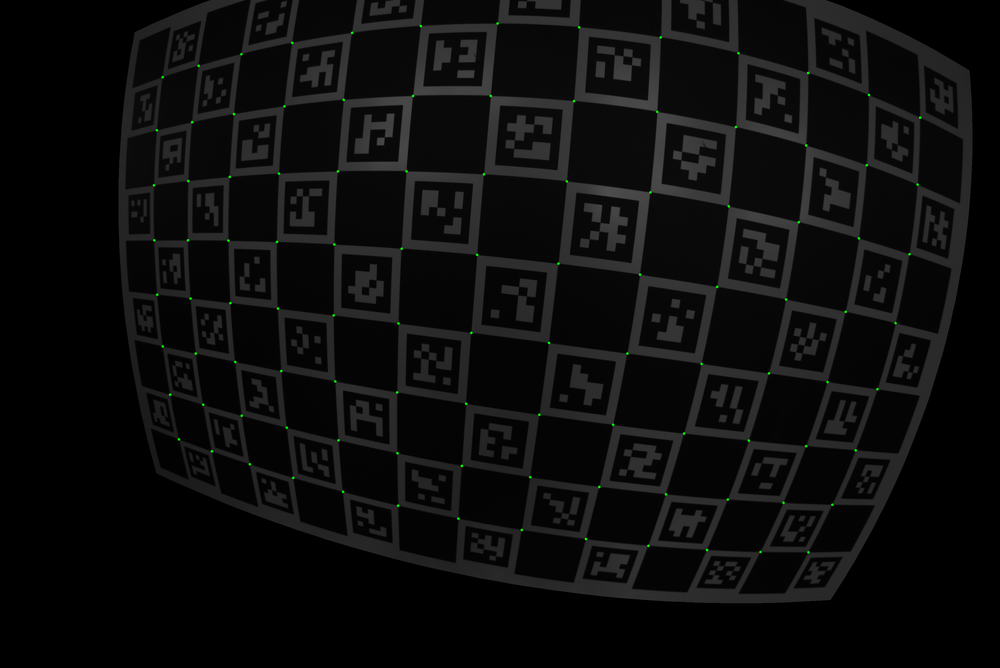

In [8]:
diagnostic = result.frame_diagnostics[0]
assert diagnostic is not None
projected_drawn = lba.draw_points(
    diagnostic.projected_points, image=used_imgs[0]
)
mediapy.show_image(projected_drawn, width=1000)

Looks good. Now let's visualize the lens distortion that the solve ended up with:

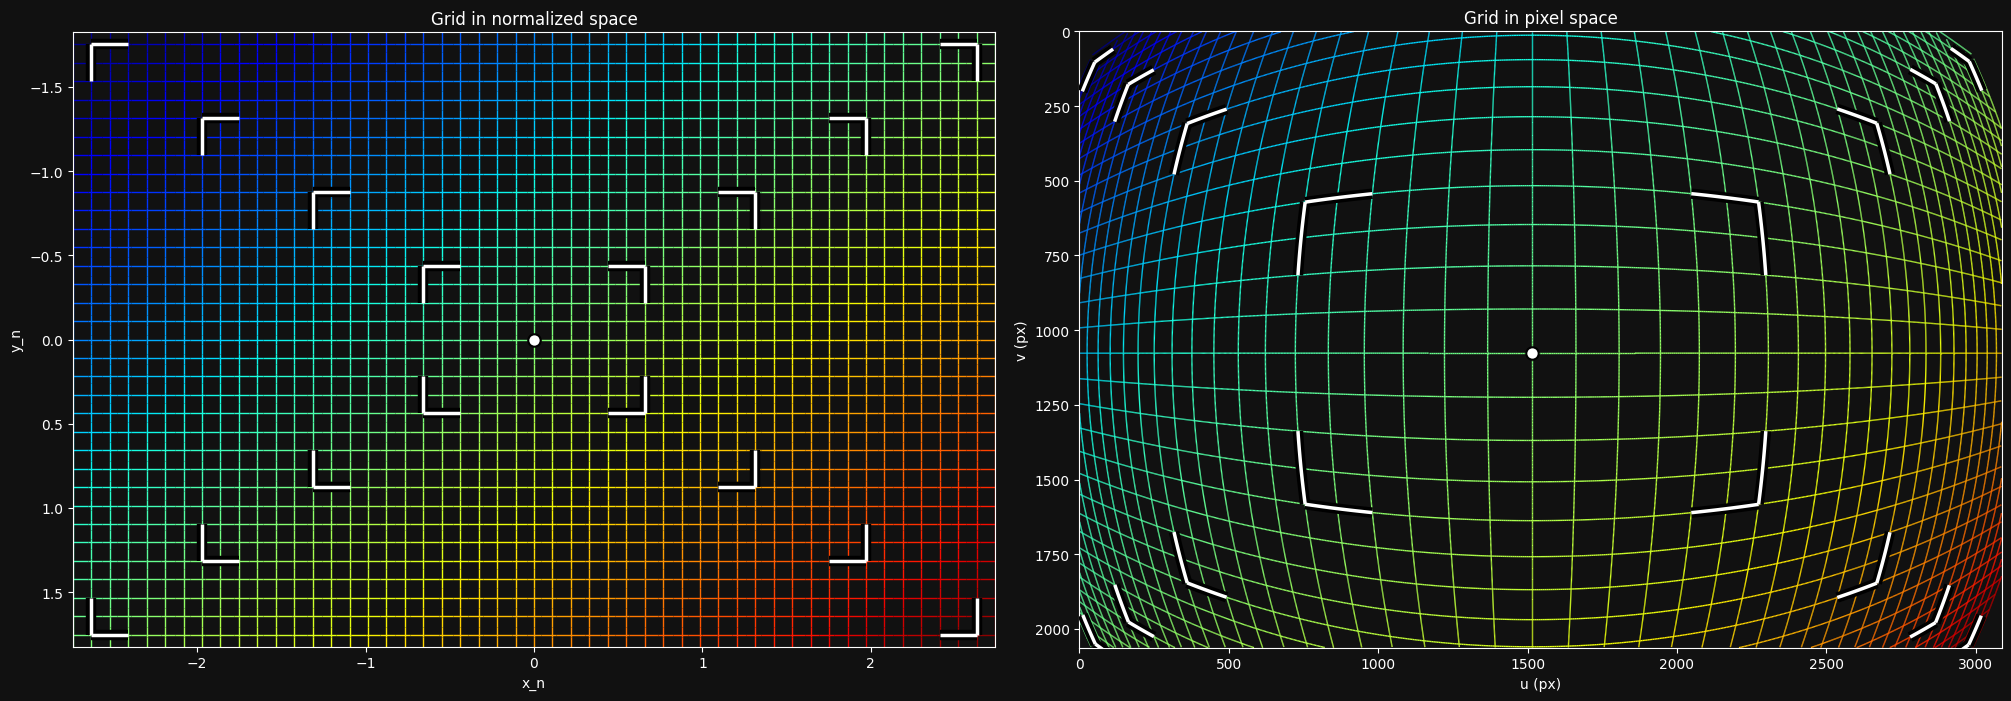

In [9]:
result.plot_distortion_grid()

The extreme distortion makes sense after looking at the images.

Let's now plot the residuals of the solve. We're looking for a tight, roughly gaussian spread, and roughly isotropic 2D residuals.

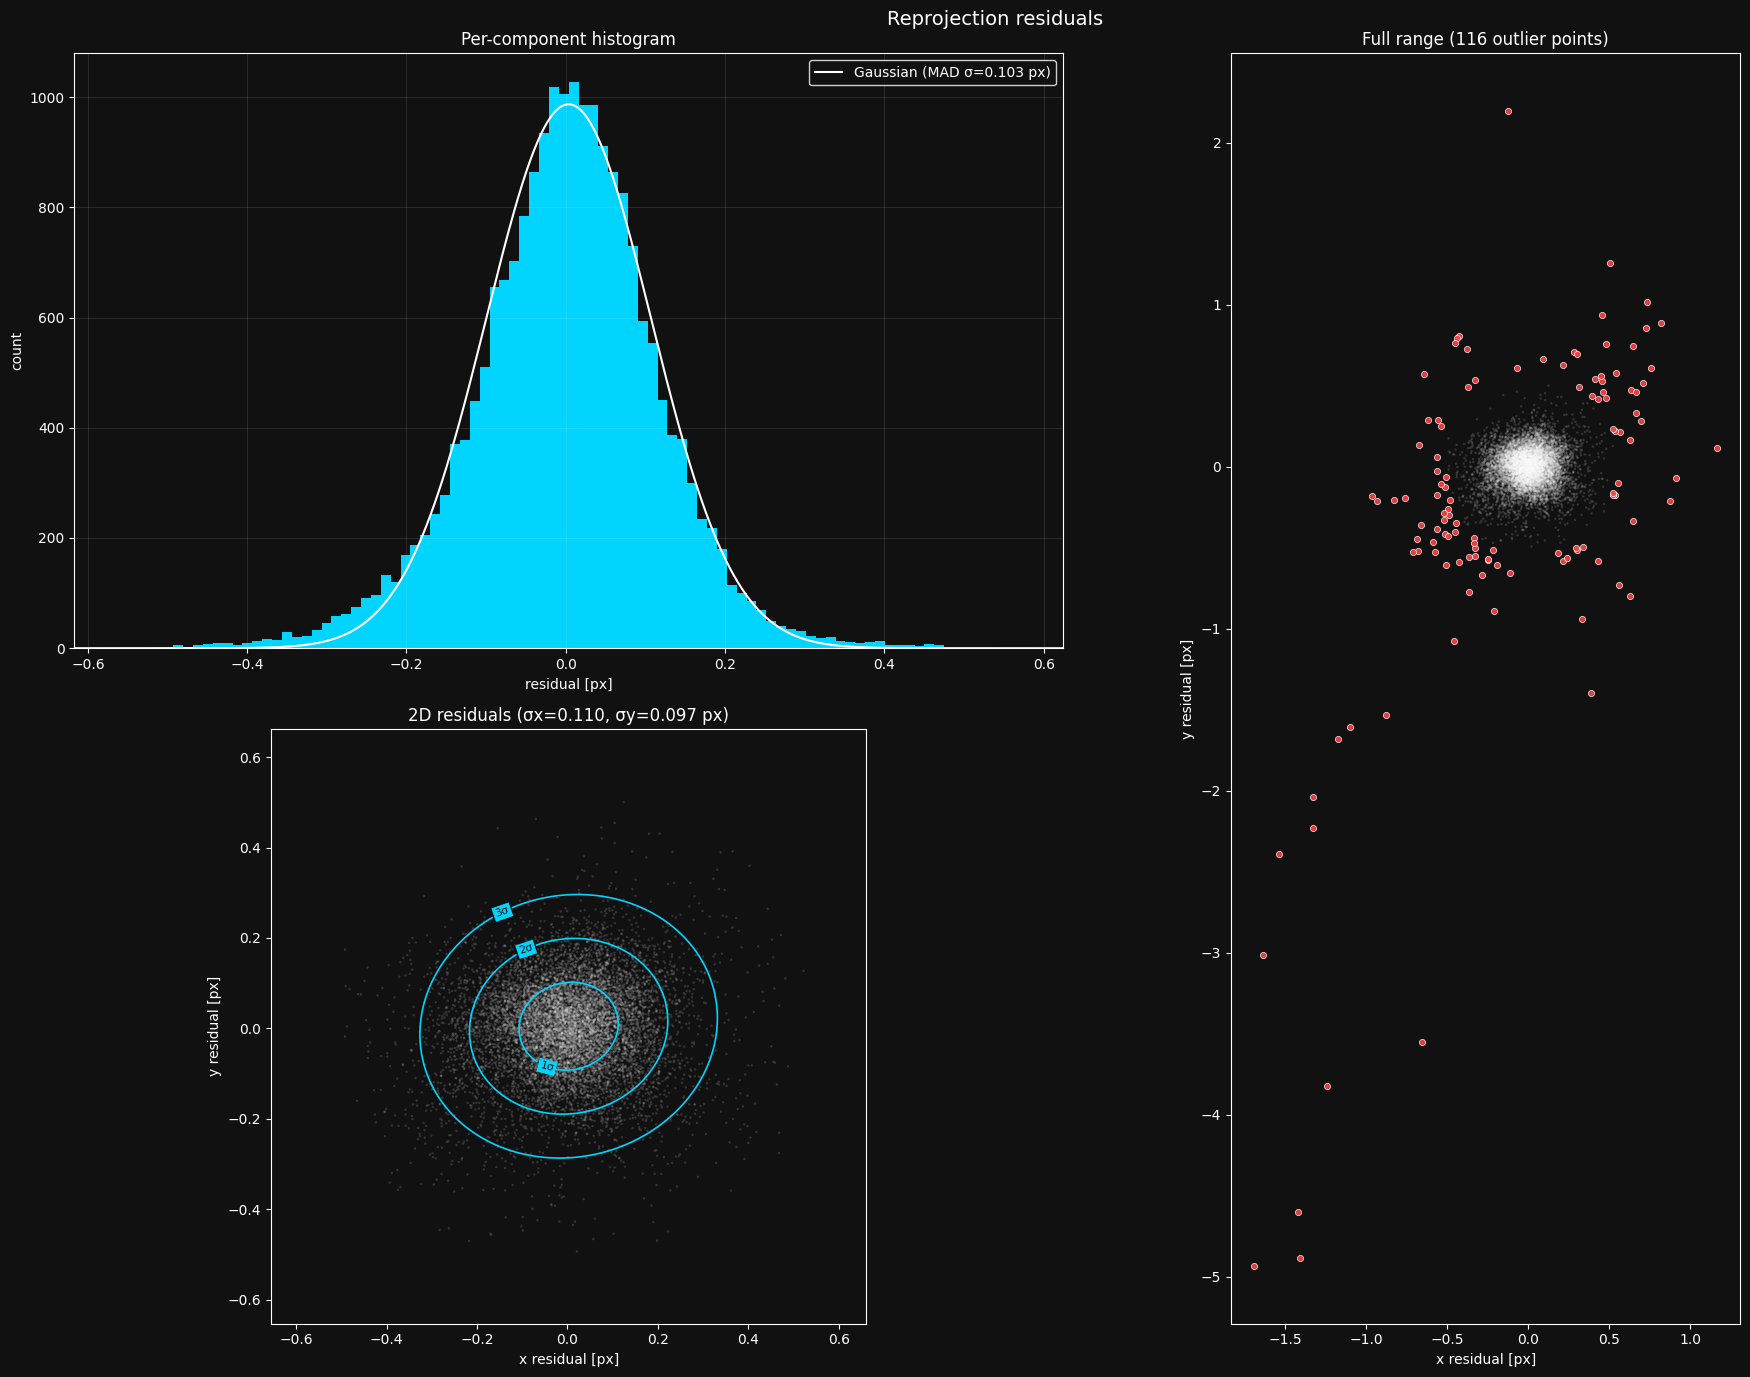

In [10]:
result.plot_residuals()

The residuals look pretty gaussian, and the spread is tight. Also, the 2D residuals look roughly isotropic, which is a good sign.

There are some pretty bad outliers. Let's see the per-image RMS of the residuals to spot where they happen:

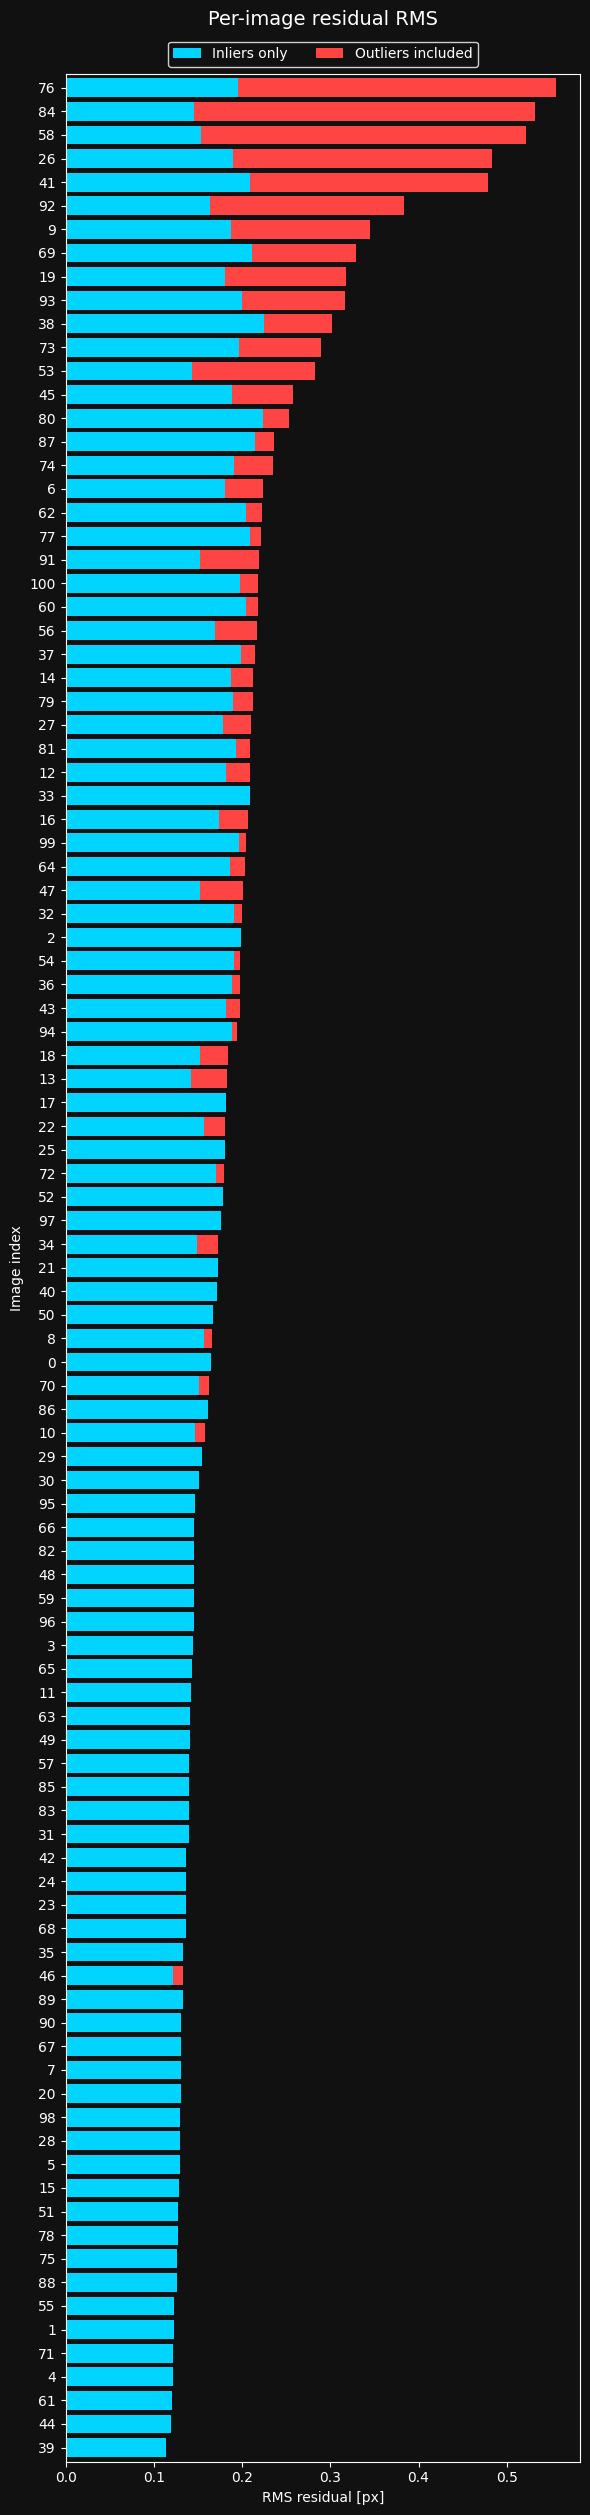

In [11]:
result.plot_per_image_rms()

Seems like some images have some particularly bad detections, but they're all filtered out as outliers. We can take a look at the worst ones:

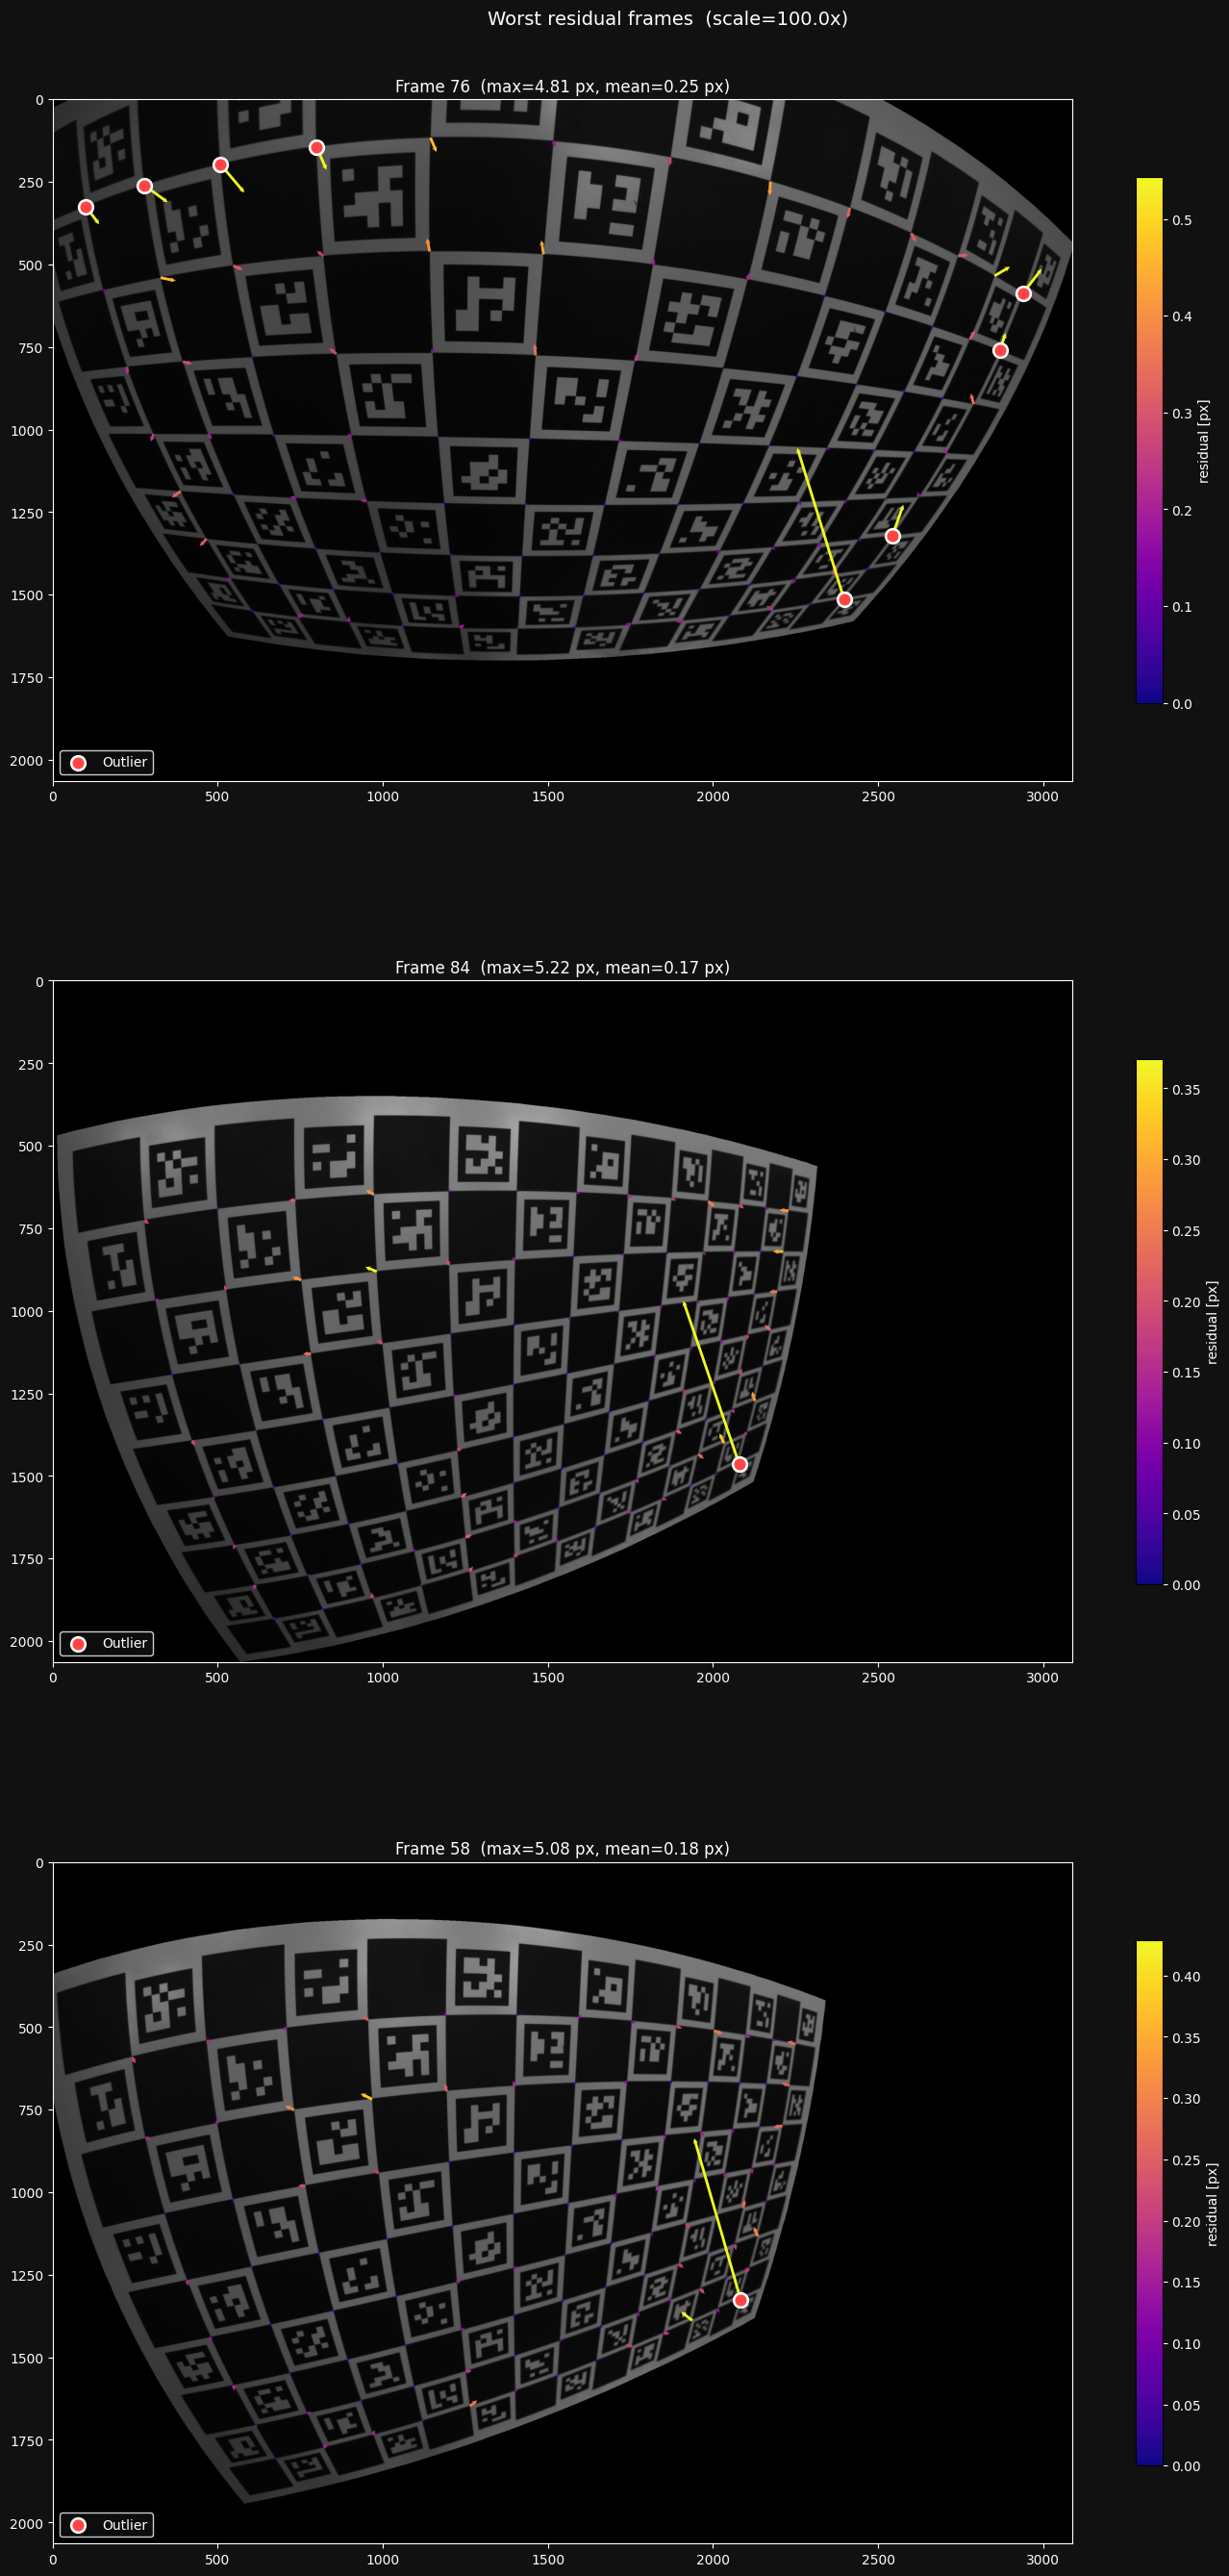

In [12]:
result.plot_worst_residual_frames(used_imgs, n=3)

This looks like some issue with the charuco detector when the board is very distorted - we will not worry about it here, since it's not too frequent, and the errors are filtered out as outliers.


Let's see if we can find any pattern in the residuals. The following plot is useful for this.

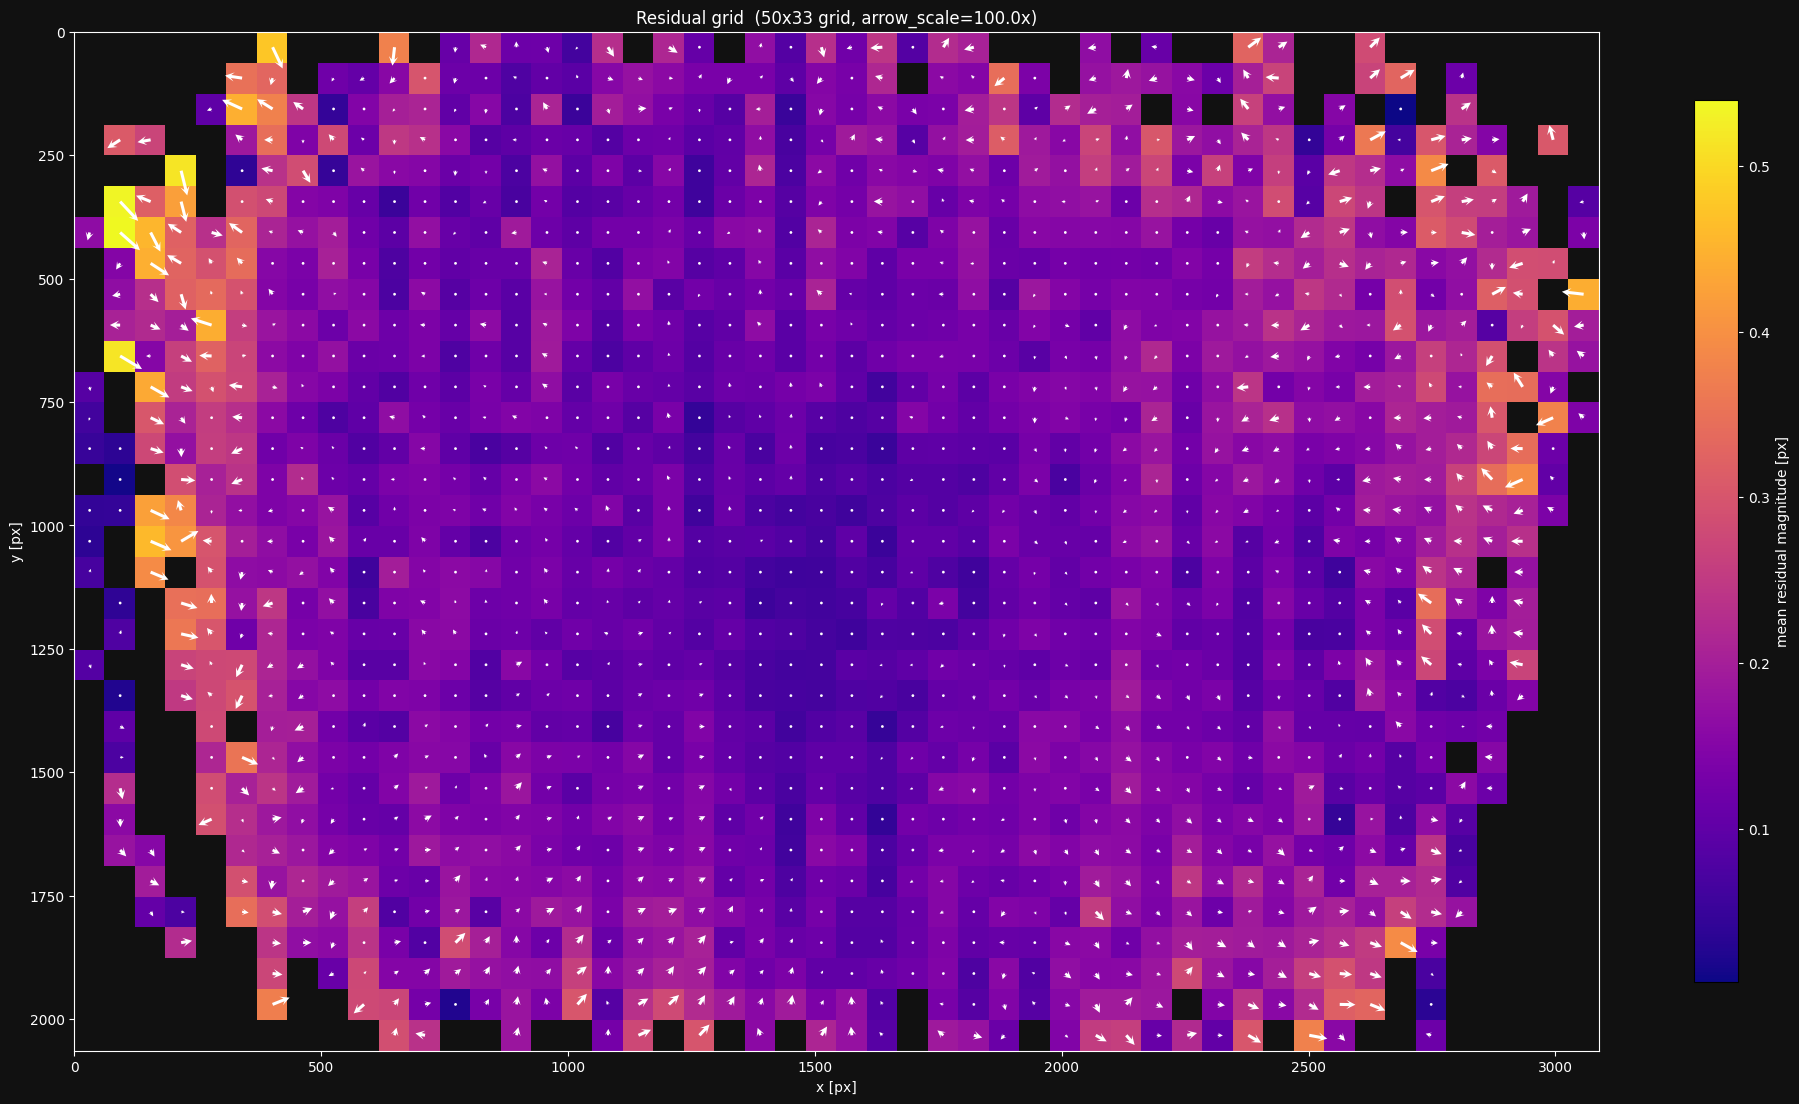

In [13]:
result.plot_residual_grid()

This plot shows the average magnitude of residuals in each cell, and plots the average residual as a vector.

Looks like the residuals are well-behaved in the center region, and become increasingly erratic at the edges. My guesses for reasons for this are:
* OpenCV models degrade slightly at the edges
* The charuco detector might have some biases under extreme distortion
* We have less data to constrain the model in the edge regions

The solver estimated the warp of the calibration target. We can take a look at this warp estimation:

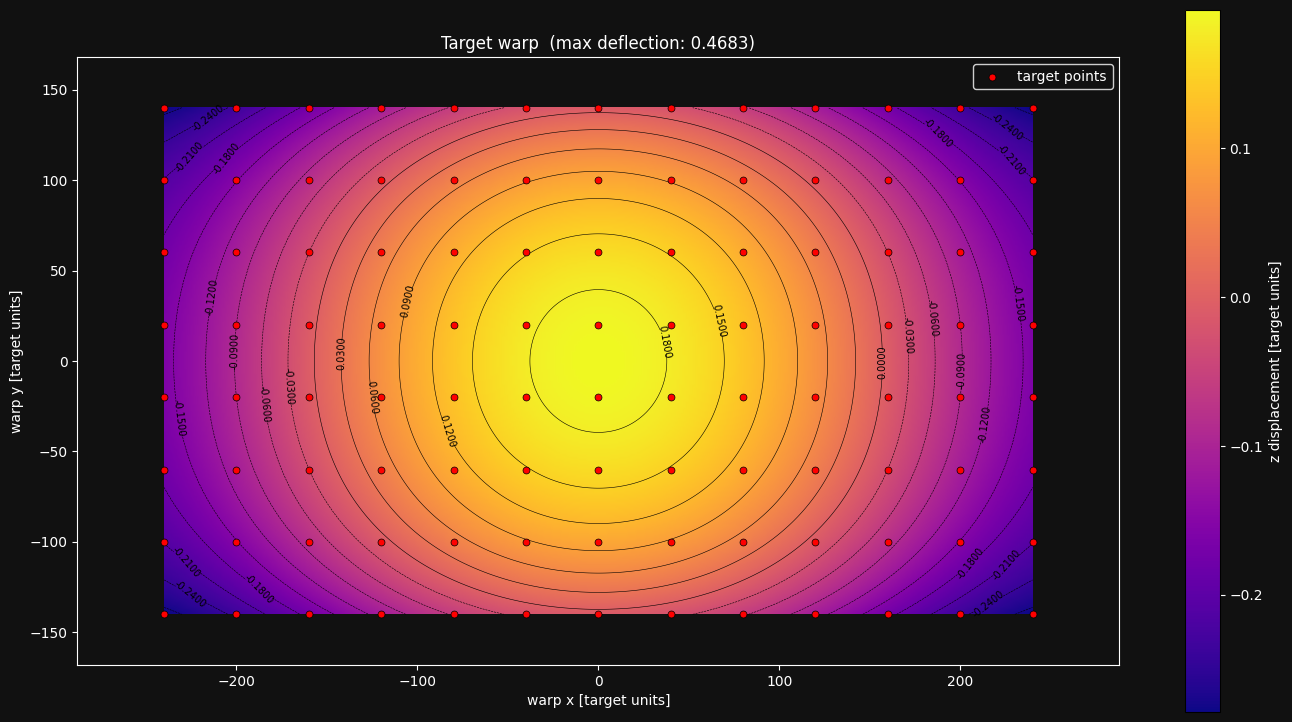

In [14]:
result.plot_target_warp()

The spread of the deflection seems to be about 0.5mm. Not so bad, but solving without the warp gives a noticeably worse fit.

# Save

When we are happy with our model, we can save it:

In [15]:
model_path = Path("../data/camera_models/opencv.json")
result.camera_model.save(model_path)